# 1. Провести полное статистическое исследование.

1) Распределение баллов

In [65]:
# Import the libraries
import matplotlib.pyplot as plt 
import pandas as pd
import numpy as np
import seaborn as sns
import math
from scipy.stats import ttest_1samp
from KDEpy import FFTKDE

## Построим **гистограмму**

Text(0.5, 0, 'Распределение баллов')

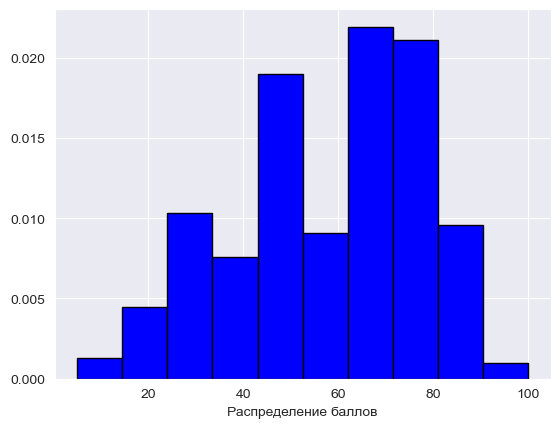

In [56]:
df = pd.read_excel('ege_2021.xlsx')

plt.hist(df['Тестовый балл'], color = 'blue', edgecolor = 'black', density=True)
plt.xlabel('Распределение баллов')

Построим **ядерную оценку плотности**

(0.0, 100.0)

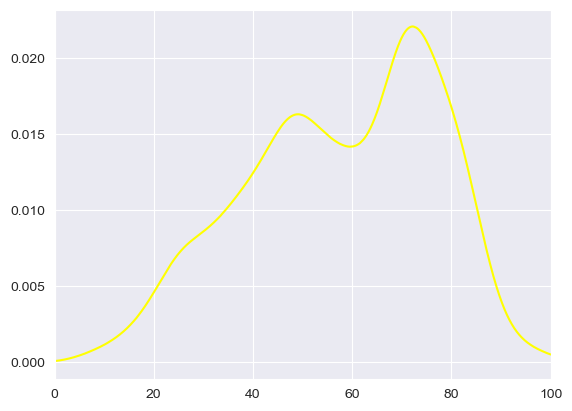

In [60]:
bw = 1.06*df['Тестовый балл'].std()*(df['Тестовый балл'].size**(-1/5))

x_corrected, y_corrected = FFTKDE(bw = bw, kernel='gaussian').fit(df['Тестовый балл'].values)(df['Тестовый балл'].size) 
plt.plot(x_corrected, y_corrected, color = 'yellow')

plt.xlim(0, 100)

In [43]:
data = df['Тестовый балл'].values

def q(dat, m):
    len2 = len(dat) + 1
    k = math.floor(m*len2)
    a = m*len2-k
    res = dat[k]+a*(dat[k+1]-dat[k])
    return res

def Med(arr):
    arr.sort()
    n = len(arr)
    if n % 2 == 0:
        return (arr[n // 2 - 1] + arr[n // 2]) / 2
    else:
        return arr[n // 2]
    
def MAD(data):
    median_value = Med(data)
    absolute_deviations = [abs(x - median_value) for x in data]
    return Med(absolute_deviations)    

print("Выборочное среднее =",data.mean())
print("Медиана выборки =", Med(data))
print("Нижний квартиль =", q(data, 0.25))
print("Верхний квартиль =", q(data, 0.75))
print("IQR =", q(data, 0.75) - q(data, 0.25))
print("Стандартное отклонение =", data.std())
print("Медиана абсолютных отклонений =", MAD(data))

Выборочное среднее = 57.729930887825624
Медиана выборки = 62
Нижний квартиль = 45.0
Верхний квартиль = 74.0
IQR = 29.0
Стандартное отклонение = 18.9982344081724
Медиана абсолютных отклонений = 14


In [46]:
df['Тестовый балл'].describe()

count    1881.000000
mean       57.729931
std        19.003286
min         5.000000
25%        45.000000
50%        62.000000
75%        74.000000
max       100.000000
Name: Тестовый балл, dtype: float64

<Axes: >

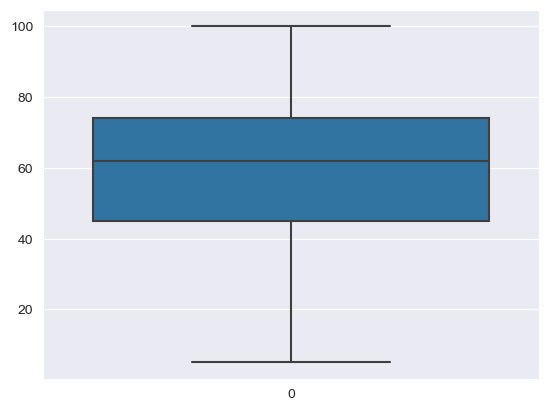

In [45]:
sns.boxplot(df['Тестовый балл'])

In [68]:
ttest_result = ttest_1samp(df['Тестовый балл'], popmean=50)
print(f"T-статистика: {ttest_result.statistic}, p-значение: {ttest_result.pvalue}")

T-статистика: 17.641734982084767, p-значение: 1.4085191607095652e-64


**1. Основная масса данных**

Гистограмма и KDE-график показывают, что основная масса данных сосредоточена в диапазоне тестовых баллов от 40 до 80. Большинство учеников набрали баллы в этом интервале, с пиком около 60-70 баллов.
**2. Симметричность/Асимметричность**

Гистограмма и KDE:

   Гистограмма и KDE показывают, что распределение тестовых баллов имеет асимметричную форму. Пики в KDE-графике указывают на правую асимметрию, так как хвост распределения тянется вправо, что говорит о наличии более высоких баллов.
   Наличие длинного правого хвоста указывает на то, что в данных присутствуют значительные выбросы или ученики, получившие высокие баллы.

**3. Центры накопления**

   Центры накопления данных находятся в интервале 50-70 баллов. Это основной диапазон, где сосредоточено большинство учеников.
   Гистограмма и KDE показывают, что наиболее плотное скопление баллов находится около 60 баллов.

**4. Диапазон всех данных без учета выбросов**

   Диапазон данных без учета выбросов:
      На основе boxplot и KDE видно, что значительная часть данных лежит в диапазоне от 30 до 80 баллов.
        Выбросы расположены за границами 25 и 85 баллов. Исключив выбросы, основной диапазон данных составляет 30-80 баллов.

**5. Количество пиков**

   Количество пиков в распределении:
        По KDE видно наличие одного ярко выраженного пика около 50 баллов.
        Возможно, есть небольшой дополнительный пик на 80 баллов, но он менее выражен.

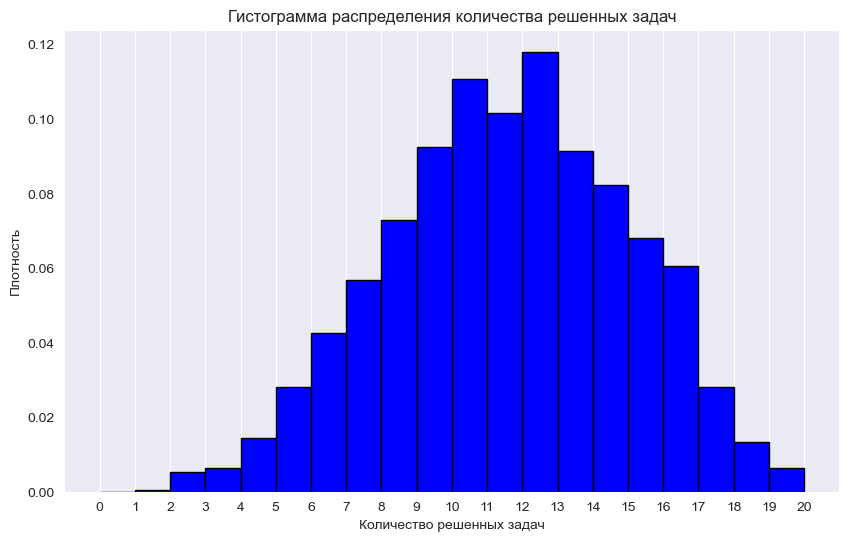

In [76]:
df = pd.read_excel('ege_2021.xlsx')

task_columns = df.loc[:, 'z1':'z19']

binary_tasks = task_columns.applymap(lambda x: 1 if x != 0 else 0)

solved_tasks = binary_tasks.sum(axis=1)

# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.hist(solved_tasks, bins=range(0, 21), color='blue', edgecolor='black', density=True)
plt.xlabel('Количество решенных задач')
plt.ylabel('Плотность')
plt.title('Гистограмма распределения количества решенных задач')
plt.xticks(range(0, 21))
plt.grid(axis='y')
plt.show()

Text(0.5, 1.0, 'Соотношение между тестовыми баллами и количеством первичных баллов')

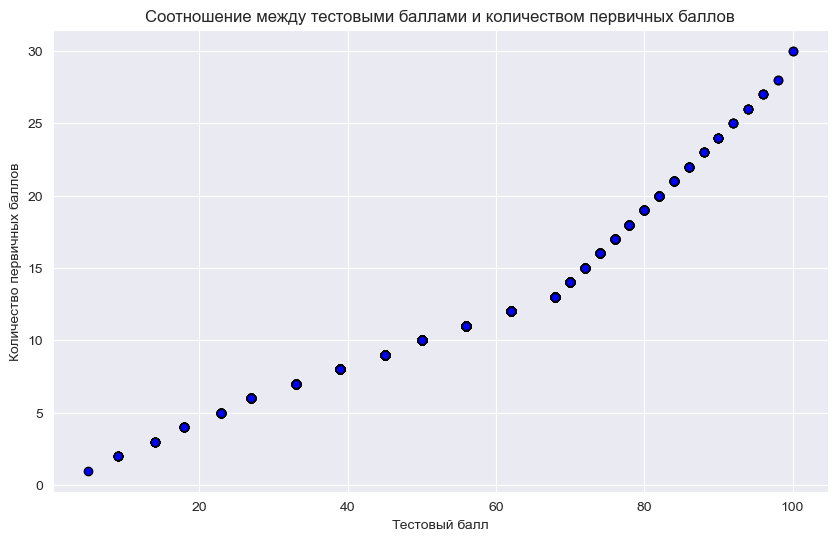

In [85]:
solved_tasks = task_columns.sum(axis=1)

# Добавление столбца с количеством решенных задач в исходный DataFrame
df['solved_tasks'] = solved_tasks

# Построение диаграммы рассеяния
plt.figure(figsize=(10, 6))
plt.scatter(df['Тестовый балл'], df['solved_tasks'], color='blue', edgecolor='black')
plt.xlabel('Тестовый балл')
plt.ylabel('Количество первичных баллов')
plt.title('Соотношение между тестовыми баллами и количеством первичных баллов')

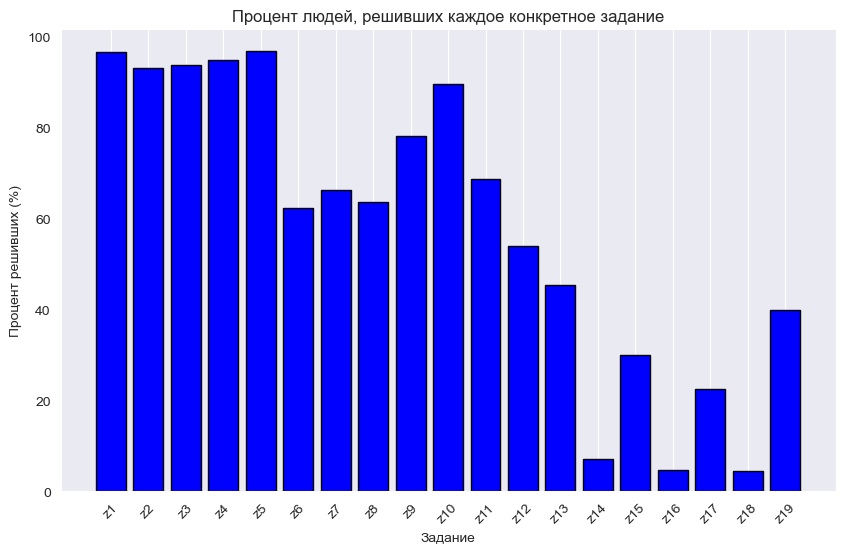

In [87]:
task_columns = df.loc[:, 'z1':'z19']

# Преобразование значений в логические (0 и 1)
binary_tasks = task_columns.applymap(lambda x: 1 if x != 0 else 0)

# Подсчет количества решенных задач для каждого задания
solved_counts = binary_tasks.sum()

# Расчет процентов решивших каждое задание
total_students = len(df)
solved_percentages = (solved_counts / total_students) * 100

# Построение гистограммы
plt.figure(figsize=(10, 6))
plt.bar(solved_percentages.index, solved_percentages.values, color='blue', edgecolor='black')
plt.xlabel('Задание')
plt.ylabel('Процент решивших (%)')
plt.title('Процент людей, решивших каждое конкретное задание')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()